<a href="https://www.kaggle.com/code/varchaswashukla/titanic-eda-survival-analysis?scriptVersionId=303119882" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Titanic EDA - Survival Analysis

## About
Exploratory Data Analysis on Titanic dataset to find 
survival patterns based on gender, class and age.

## Key Findings
- Only 38% passengers survived
- 74% females survived vs 19% males  
- 1st class had 63% survival vs 24% in 3rd class
- Most passengers were aged 20-30

## Tools Used
Python | Pandas | Matplotlib | Seaborn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# Basic info
print(df.shape)
print(df['Survived'].value_counts())

# Survival rate by gender
print(df.groupby('Sex')['Survived'].mean())

(891, 12)
Survived
0    549
1    342
Name: count, dtype: int64
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


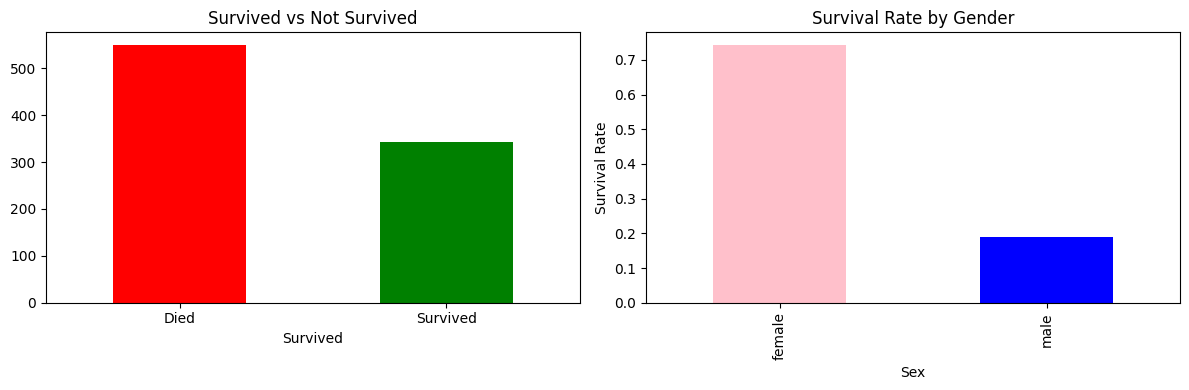

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graph 1: Survived vs Not Survived
df['Survived'].value_counts().plot(kind='bar', ax=axes[0], color=['red', 'green'])
axes[0].set_title('Survived vs Not Survived')
axes[0].set_xticklabels(['Died', 'Survived'], rotation=0)

# Graph 2: Survival by Gender
df.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[1], color=['pink', 'blue'])
axes[1].set_title('Survival Rate by Gender')
axes[1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

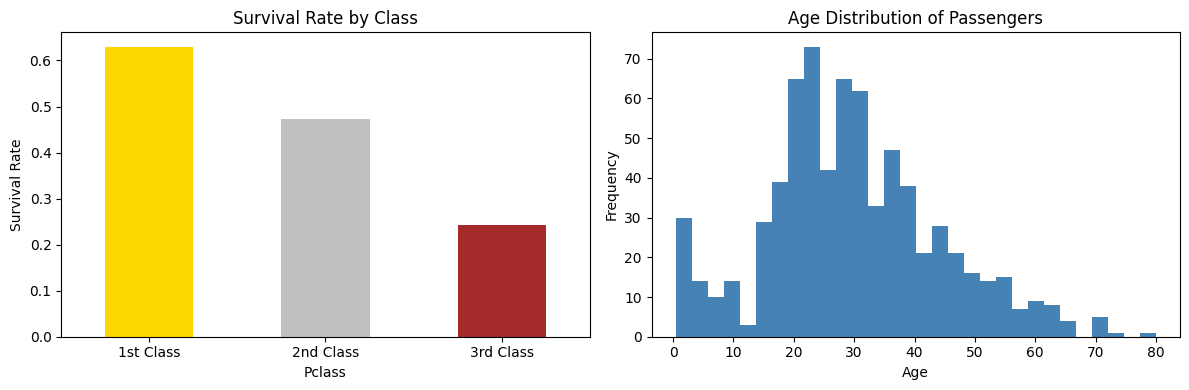

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graph 1: Survival by Class
df.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[0], color=['gold', 'silver', 'brown'])
axes[0].set_title('Survival Rate by Class')
axes[0].set_ylabel('Survival Rate')
axes[0].set_xticklabels(['1st Class', '2nd Class', '3rd Class'], rotation=0)

# Graph 2: Age distribution
df['Age'].dropna().plot(kind='hist', ax=axes[1], bins=30, color='steelblue')
axes[1].set_title('Age Distribution of Passengers')
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.show()